### Imports


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from skimage.feature import hog, local_binary_pattern
from skimage import exposure
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

### Load dataset

In [4]:
train_path = Path('seg_train/seg_train')
test_path = Path('seg_test/seg_test')

categories = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

def load_dataset(data_path, categories, max_images_per_class=None):
    images = []
    labels = []
    
    for category in categories:
        category_path = data_path / category
        image_files = list(category_path.glob('*.jpg'))
        
        if max_images_per_class:
            image_files = image_files[:max_images_per_class]
        
        print(f"Loading {len(image_files)} images from {category}...")
        
        for img_path in image_files:
            img = cv2.imread(str(img_path))
            if img is not None:
                images.append(img)
                labels.append(category)
    
    return images, labels

print("Loading training dataset...")
train_images, train_labels = load_dataset(train_path, categories)
print(f"Loaded {len(train_images)} training images")

print("\nLoading test dataset...")
test_images, test_labels = load_dataset(test_path, categories)
print(f"Loaded {len(test_images)} test images")

Loading training dataset...
Loading 2191 images from buildings...
Loading 2271 images from forest...
Loading 2404 images from glacier...
Loading 2512 images from mountain...
Loading 2274 images from sea...
Loading 2382 images from street...
Loaded 14034 training images

Loading test dataset...
Loading 437 images from buildings...
Loading 474 images from forest...
Loading 553 images from glacier...
Loading 525 images from mountain...
Loading 510 images from sea...
Loading 501 images from street...
Loaded 3000 test images


### Preprocessing

In [5]:
def preprocess_image(image, target_size=(128, 128)):
    img = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    img_gray = cv2.equalizeHist(img_gray)
    
    return img, img_gray

print("Preprocessing images...")
train_processed = []
train_gray = []

for img in tqdm(train_images):
    img_rgb, img_g = preprocess_image(img)
    train_processed.append(img_rgb)
    train_gray.append(img_g)

test_processed = []
test_gray = []

for img in tqdm(test_images):
    img_rgb, img_g = preprocess_image(img)
    test_processed.append(img_rgb)
    test_gray.append(img_g)

print("Preprocessing complete!")

Preprocessing images...


100%|██████████| 3000/3000 [00:00<00:00, 4935.67it/s]

Preprocessing complete!


### Feature extraction

In [6]:
def extract_color_histogram(image, bins=32):
    hist_features = []
    for channel in range(3):
        hist = cv2.calcHist([image], [channel], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.extend(hist)
    return np.array(hist_features)

def extract_hog_features(image_gray):
    features = hog(image_gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), visualize=False, channel_axis=None)
    return features

def extract_lbp_features(image_gray, num_points=24, radius=3):
    lbp = local_binary_pattern(image_gray, num_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=num_points + 2, range=(0, num_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

def extract_texture_features(image_gray):
    mean = np.mean(image_gray)
    std = np.std(image_gray)
    skewness = ((image_gray - mean) ** 3).mean() / (std ** 3 + 1e-7)
    kurtosis = ((image_gray - mean) ** 4).mean() / (std ** 4 + 1e-7)
    
    return np.array([mean, std, skewness, kurtosis])

def extract_all_features(image_rgb, image_gray):
    color_hist = extract_color_histogram(image_rgb)
    hog_feat = extract_hog_features(image_gray)
    lbp_feat = extract_lbp_features(image_gray)
    texture_feat = extract_texture_features(image_gray)
    
    all_features = np.concatenate([color_hist, hog_feat, lbp_feat, texture_feat])
    return all_features

print("Extracting features from training set...")
train_features = []
for img_rgb, img_gray in tqdm(zip(train_processed, train_gray), total=len(train_processed)):
    features = extract_all_features(img_rgb, img_gray)
    train_features.append(features)

train_features = np.array(train_features)
print(f"Training features shape: {train_features.shape}")

print("\nExtracting features from test set...")
test_features = []
for img_rgb, img_gray in tqdm(zip(test_processed, test_gray), total=len(test_processed)):
    features = extract_all_features(img_rgb, img_gray)
    test_features.append(features)

test_features = np.array(test_features)
print(f"Test features shape: {test_features.shape}")

Extracting features from training set...


100%|██████████| 14034/14034 [02:36<00:00, 89.46it/s] 


Training features shape: (14034, 8226)

Extracting features from test set...


100%|██████████| 3000/3000 [00:39<00:00, 76.36it/s]


Test features shape: (3000, 8226)


### Encode labels

In [7]:
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
test_labels_encoded = le.transform(test_labels)

print(f"Classes: {le.classes_}")
print(f"Number of samples per class:")
unique, counts = np.unique(train_labels_encoded, return_counts=True)
for cls, count in zip(le.classes_, counts):
    print(f"  {cls}: {count}")

Classes: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']
Number of samples per class:
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382


### Feature scaling

In [8]:
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

print(f"Scaled features shape: {train_features_scaled.shape}")
print(f"Feature mean: {train_features_scaled.mean():.4f}")
print(f"Feature std: {train_features_scaled.std():.4f}")

Scaled features shape: (14034, 8226)
Feature mean: 0.0000
Feature std: 1.0000


### PCA

In [9]:
pca = PCA(n_components=0.95, random_state=42)
train_features_pca = pca.fit_transform(train_features_scaled)
test_features_pca = pca.transform(test_features_scaled)

print(f"Original features: {train_features_scaled.shape[1]}")
print(f"PCA features (95% variance): {train_features_pca.shape[1]}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Dimensionality reduction: {(1 - train_features_pca.shape[1]/train_features_scaled.shape[1])*100:.1f}%")

Original features: 8226
PCA features (95% variance): 1931
Explained variance: 0.9501
Dimensionality reduction: 76.5%


In [10]:
print("="*70)
print("PREPROCESSING & FEATURE EXTRACTION SUMMARY")
print("="*70)

print("\n1. PREPROCESSING:")
print(f"   - Target image size: 128 x 128")
print(f"   - Color space: BGR → RGB")
print(f"   - Grayscale conversion: Applied")
print(f"   - Histogram equalization: Applied to grayscale images")

print("\n2. FEATURE EXTRACTION:")
print(f"   - Color Histogram: 32 bins × 3 channels = 96 features")
print(f"   - HOG Features: 9 orientations, 8×8 pixels/cell, 2×2 cells/block")
print(f"   - LBP Features: 24 points, radius 3 (26 features)")
print(f"   - Texture Features: {len(texture_desc)} features {texture_desc}")
print(f"   - Total extracted features: {train_features.shape[1]}")

print("\n3. DIMENSIONALITY REDUCTION:")
print(f"   - Method: PCA (95% variance retained)")
print(f"   - Original features: {train_features.shape[1]}")
print(f"   - Reduced features: {train_features_pca.shape[1]}")
print(f"   - Reduction: {(1 - train_features_pca.shape[1]/train_features.shape[1])*100:.1f}%")

print("="*70)

PREPROCESSING & FEATURE EXTRACTION SUMMARY

1. PREPROCESSING:
   - Target image size: 128 x 128
   - Color space: BGR → RGB
   - Grayscale conversion: Applied
   - Histogram equalization: Applied to grayscale images

2. FEATURE EXTRACTION:
   - Color Histogram: 32 bins × 3 channels = 96 features
   - HOG Features: 9 orientations, 8×8 pixels/cell, 2×2 cells/block
   - LBP Features: 24 points, radius 3 (26 features)


NameError: name 'texture_desc' is not defined

### PCA Plot

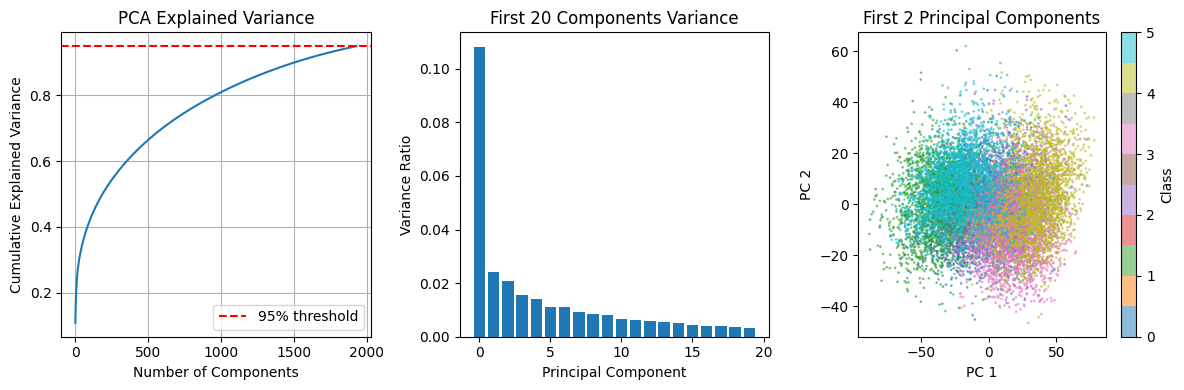

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.bar(range(min(20, len(pca.explained_variance_ratio_))), 
        pca.explained_variance_ratio_[:20])
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('First 20 Components Variance')

plt.subplot(1, 3, 3)
component_idx = 0
plt.scatter(train_features_pca[:, component_idx], 
            train_features_pca[:, component_idx+1], 
            c=train_labels_encoded, cmap='tab10', alpha=0.5, s=1)
plt.xlabel(f'PC {component_idx+1}')
plt.ylabel(f'PC {component_idx+2}')
plt.title('First 2 Principal Components')
plt.colorbar(label='Class')

plt.tight_layout()
plt.show()

### Plot samples

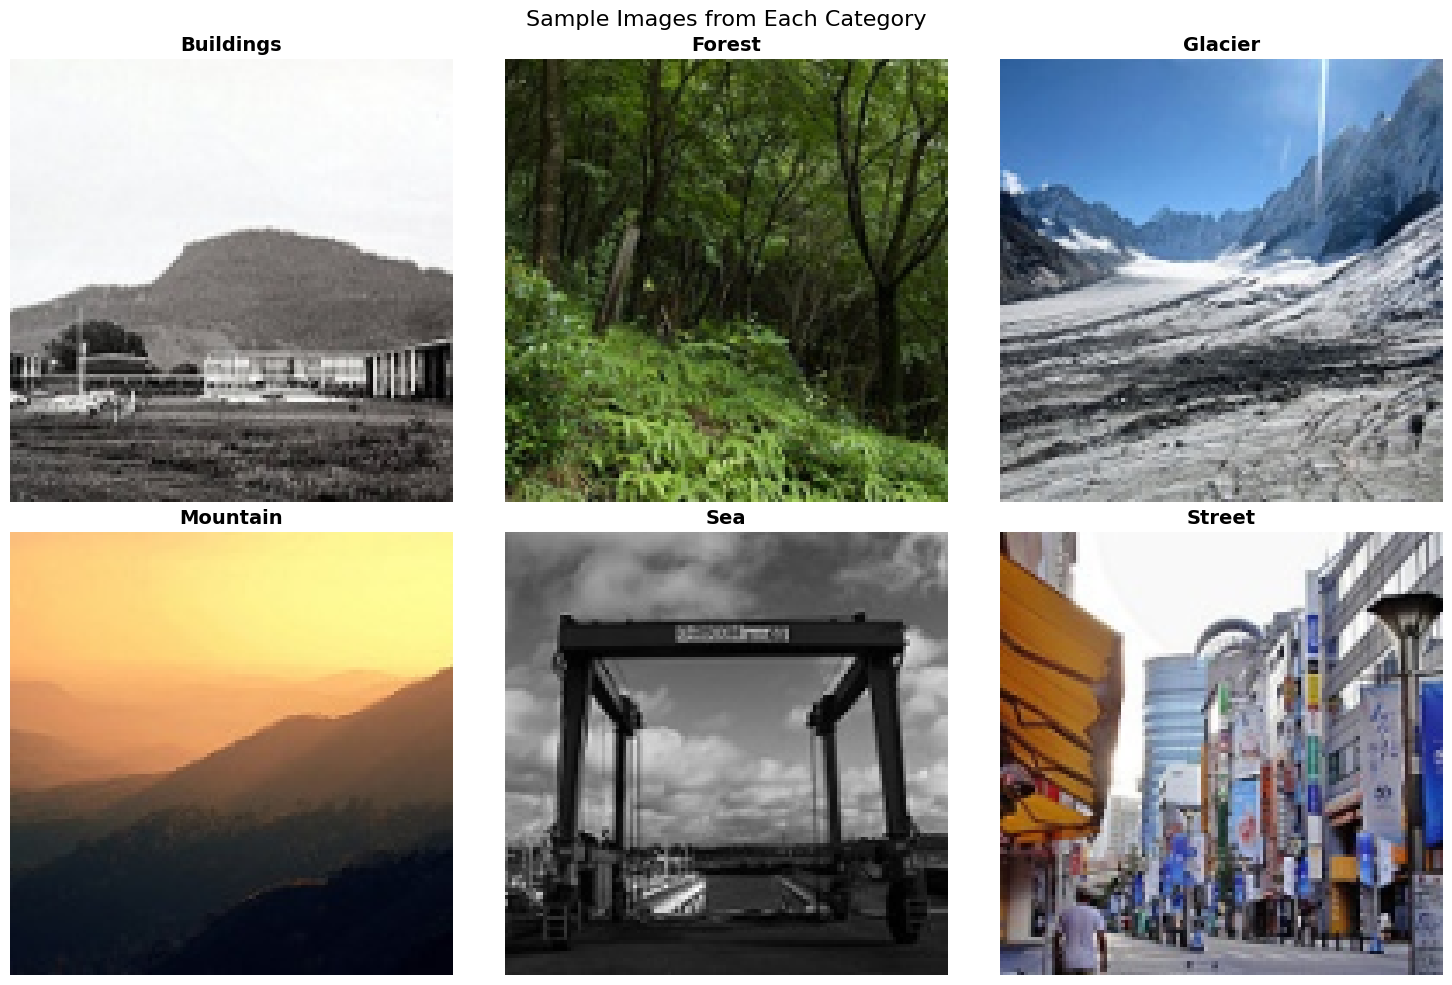

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, category in enumerate(categories):
    sample_idx = train_labels.index(category)
    axes[idx // 3, idx % 3].imshow(train_processed[sample_idx])
    axes[idx // 3, idx % 3].set_title(f'{category.capitalize()}', fontsize=14, fontweight='bold')
    axes[idx // 3, idx % 3].axis('off')

plt.suptitle('Sample Images from Each Category', fontsize=16)
plt.tight_layout()
plt.show()

## Decision Tree Classification

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

In [20]:
dt_classifier = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=30,
    min_samples_leaf=20,
    random_state=42
)

print("Training Decision Tree...")
start_time = time.time()
dt_classifier.fit(train_features_pca, train_labels_encoded)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds")

Training Decision Tree...
Training completed in 24.55 seconds


In [21]:
print("Making predictions...")
start_time = time.time()
dt_train_pred = dt_classifier.predict(train_features_pca)
dt_test_pred = dt_classifier.predict(test_features_pca)
prediction_time = time.time() - start_time

dt_train_accuracy = accuracy_score(train_labels_encoded, dt_train_pred)
dt_test_accuracy = accuracy_score(test_labels_encoded, dt_test_pred)

print(f"Prediction completed in {prediction_time:.2f} seconds")
print(f"\nTraining Accuracy: {dt_train_accuracy:.4f} ({dt_train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {dt_test_accuracy:.4f} ({dt_test_accuracy*100:.2f}%)")

Making predictions...
Prediction completed in 0.13 seconds

Training Accuracy: 0.6419 (64.19%)
Test Accuracy: 0.6030 (60.30%)


In [24]:
print("Classification Report (Test Set):")
print("="*60)
print(classification_report(test_labels_encoded, dt_test_pred, target_names=le.classes_))

Classification Report (Test Set):
              precision    recall  f1-score   support

   buildings       0.64      0.70      0.67       437
      forest       0.84      0.88      0.85       474
     glacier       0.43      0.63      0.51       553
    mountain       0.51      0.35      0.42       525
         sea       0.65      0.49      0.56       510
      street       0.66      0.60      0.63       501

    accuracy                           0.60      3000
   macro avg       0.62      0.61      0.61      3000
weighted avg       0.61      0.60      0.60      3000



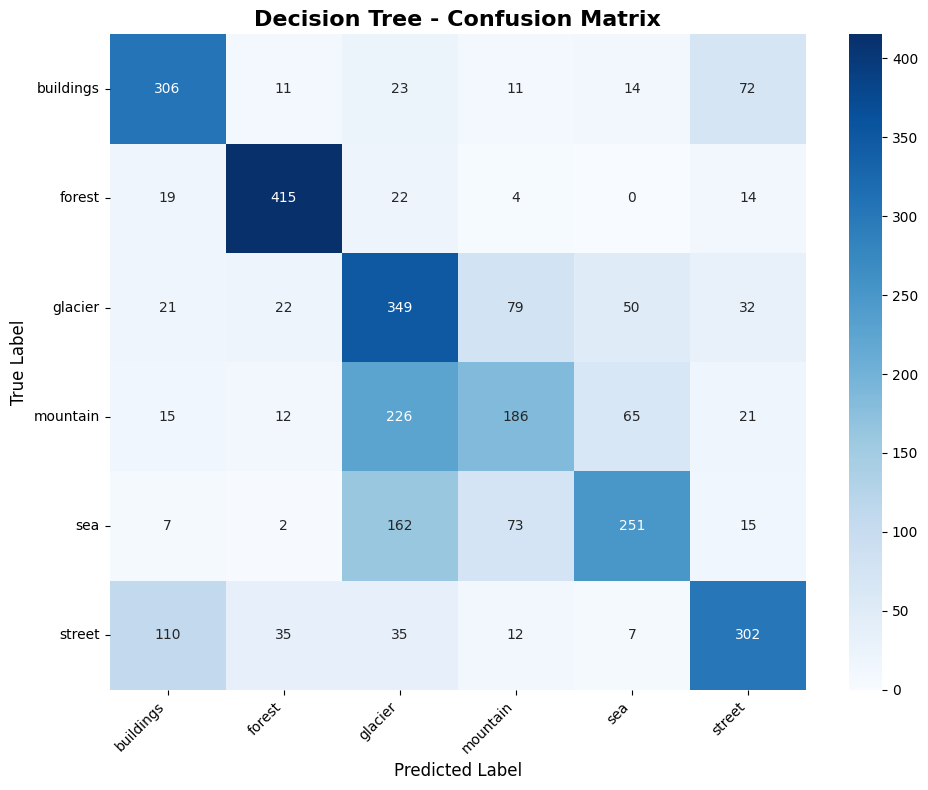


Confusion Matrix Shape: (6, 6)
Diagonal sum (correct predictions): 1809
Total predictions: 3000


In [26]:
cm_dt = confusion_matrix(test_labels_encoded, dt_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Decision Tree - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Shape: {cm_dt.shape}")
print(f"Diagonal sum (correct predictions): {np.trace(cm_dt)}")
print(f"Total predictions: {cm_dt.sum()}")

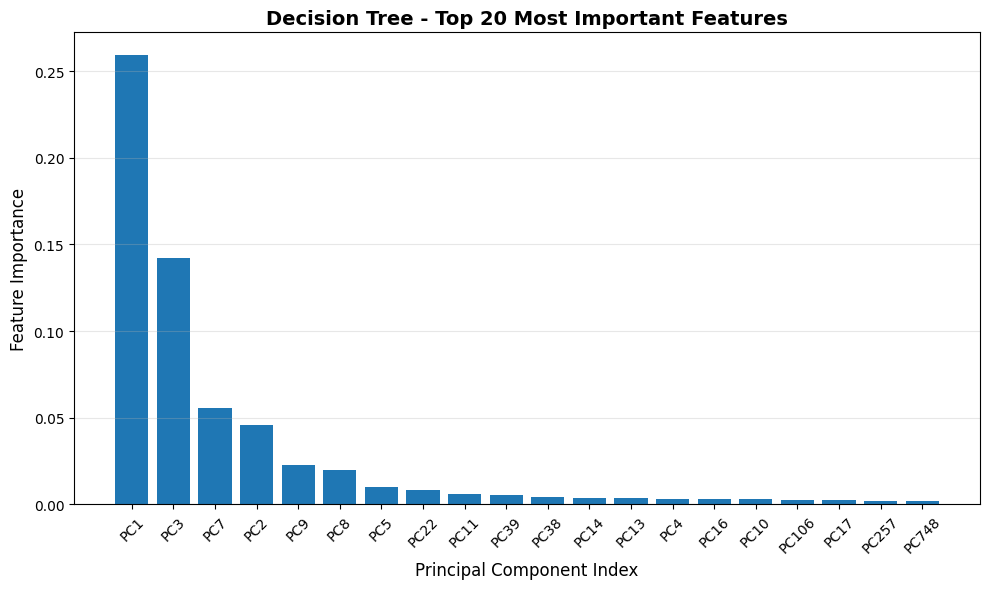


Top 5 most important features:
  PC1: 0.2594
  PC3: 0.1424
  PC7: 0.0555
  PC2: 0.0457
  PC9: 0.0225


In [25]:
feature_importance = dt_classifier.feature_importances_
top_n = 20
top_features_idx = np.argsort(feature_importance)[-top_n:][::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), feature_importance[top_features_idx])
plt.xlabel('Principal Component Index', fontsize=12)
plt.ylabel('Feature Importance', fontsize=12)
plt.title('Decision Tree - Top 20 Most Important Features', fontsize=14, fontweight='bold')
plt.xticks(range(top_n), [f'PC{i+1}' for i in top_features_idx], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important features:")
for i in range(5):
    idx = top_features_idx[i]
    print(f"  PC{idx+1}: {feature_importance[idx]:.4f}")

In [22]:
print("="*70)
print("DECISION TREE CLASSIFIER SUMMARY")
print("="*70)

print("\n1. MODEL PARAMETERS:")
print(f"   - Max depth: {dt_classifier.max_depth}")
print(f"   - Min samples split: {dt_classifier.min_samples_split}")
print(f"   - Min samples leaf: {dt_classifier.min_samples_leaf}")
print(f"   - Actual tree depth: {dt_classifier.get_depth()}")
print(f"   - Number of leaves: {dt_classifier.get_n_leaves()}")

print("\n2. DATASET:")
print(f"   - Training samples: {len(train_features_pca)}")
print(f"   - Test samples: {len(test_features_pca)}")
print(f"   - Number of features: {train_features_pca.shape[1]} (PCA components)")
print(f"   - Number of classes: {len(le.classes_)}")

print("\n3. PERFORMANCE:")
print(f"   - Training accuracy: {dt_train_accuracy:.4f} ({dt_train_accuracy*100:.2f}%)")
print(f"   - Test accuracy: {dt_test_accuracy:.4f} ({dt_test_accuracy*100:.2f}%)")
print(f"   - Training time: {training_time:.2f} seconds")
print(f"   - Prediction time: {prediction_time:.2f} seconds")

overfitting = dt_train_accuracy - dt_test_accuracy
print(f"\n4. OVERFITTING CHECK:")
print(f"   - Train-Test gap: {overfitting:.4f} ({overfitting*100:.2f}%)")
if overfitting > 0.1:
    print("   - Warning: Significant overfitting detected")
elif overfitting > 0.05:
    print("   - Note: Moderate overfitting")
else:
    print("   - Good: Minimal overfitting")

print("="*70)

DECISION TREE CLASSIFIER SUMMARY

1. MODEL PARAMETERS:
   - Max depth: 6
   - Min samples split: 30
   - Min samples leaf: 20
   - Actual tree depth: 6
   - Number of leaves: 64

2. DATASET:
   - Training samples: 14034
   - Test samples: 3000
   - Number of features: 1931 (PCA components)
   - Number of classes: 6

3. PERFORMANCE:
   - Training accuracy: 0.6419 (64.19%)
   - Test accuracy: 0.6030 (60.30%)
   - Training time: 24.55 seconds
   - Prediction time: 0.13 seconds

4. OVERFITTING CHECK:
   - Train-Test gap: 0.0389 (3.89%)
   - Good: Minimal overfitting


## Support Vector Machine (SVM) Classification

In [29]:
from sklearn.svm import SVC

In [ ]:
print("="*70)
print("Training SVM with RBF kernel...")
print("="*70)

svm_rbf = SVC(
  kernel='rbf', 
  C=1.0, 
  gamma='scale', 
  random_state=42, verbose=True)

print("\n[1/3] Fitting model to training data...")
start_time = time.time()
svm_rbf.fit(train_features_pca, train_labels_encoded)
svm_training_time = time.time() - start_time
print(f"Training completed in {svm_training_time:.2f} seconds")

print("\n[2/3] Making predictions on training set...")
start_time = time.time()
svm_train_pred = svm_rbf.predict(train_features_pca)
train_pred_time = time.time() - start_time
print(f"Training predictions completed in {train_pred_time:.2f} seconds")

print("\n[3/3] Making predictions on test set...")
start_time = time.time()
svm_test_pred = svm_rbf.predict(test_features_pca)
test_pred_time = time.time() - start_time
print(f"Test predictions completed in {test_pred_time:.2f} seconds")

svm_prediction_time = train_pred_time + test_pred_time

svm_train_accuracy = accuracy_score(train_labels_encoded, svm_train_pred)
svm_test_accuracy = accuracy_score(test_labels_encoded, svm_test_pred)

print(f"\n{'='*70}")
print("RESULTS:")
print(f"Training accuracy: {svm_train_accuracy:.4f} ({svm_train_accuracy*100:.2f}%)")
print(f"Test accuracy: {svm_test_accuracy:.4f} ({svm_test_accuracy*100:.2f}%)")
print(f"Total training time: {svm_training_time:.2f} seconds")
print(f"Total prediction time: {svm_prediction_time:.2f} seconds")
print(f"{'='*70}")

Training SVM with RBF kernel...

[1/3] Fitting model to training data...
[LibSVM][LibSVM]Training completed in 94.44 seconds

[2/3] Making predictions on training set...
Training completed in 94.44 seconds

[2/3] Making predictions on training set...
Training predictions completed in 293.76 seconds

[3/3] Making predictions on test set...
Training predictions completed in 293.76 seconds

[3/3] Making predictions on test set...
Test predictions completed in 45.88 seconds

RESULTS:
Training accuracy: 0.9607 (96.07%)
Test accuracy: 0.7797 (77.97%)
Total training time: 94.44 seconds
Total prediction time: 339.63 seconds
Test predictions completed in 45.88 seconds

RESULTS:
Training accuracy: 0.9607 (96.07%)
Test accuracy: 0.7797 (77.97%)
Total training time: 94.44 seconds
Total prediction time: 339.63 seconds


In [32]:
print("Classification Report (Test Set):")
print("="*70)
print(classification_report(test_labels_encoded, svm_test_pred, target_names=le.classes_))

Classification Report (Test Set):
              precision    recall  f1-score   support

   buildings       0.85      0.78      0.82       437
      forest       0.91      0.97      0.94       474
     glacier       0.68      0.70      0.69       553
    mountain       0.65      0.70      0.67       525
         sea       0.75      0.70      0.72       510
      street       0.86      0.85      0.85       501

    accuracy                           0.78      3000
   macro avg       0.79      0.78      0.78      3000
weighted avg       0.78      0.78      0.78      3000



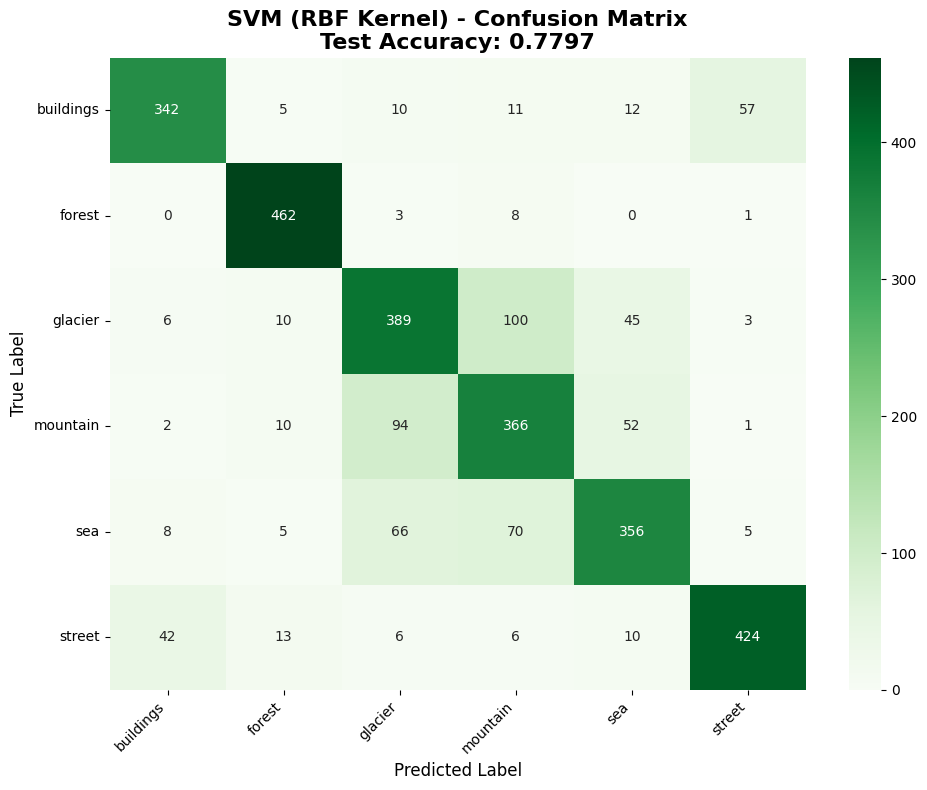


Confusion Matrix Shape: (6, 6)
Diagonal sum (correct predictions): 2339
Total predictions: 3000


In [33]:
cm_svm = confusion_matrix(test_labels_encoded, svm_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'SVM (RBF Kernel) - Confusion Matrix\nTest Accuracy: {svm_test_accuracy:.4f}',
          fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Shape: {cm_svm.shape}")
print(f"Diagonal sum (correct predictions): {np.trace(cm_svm)}")
print(f"Total predictions: {cm_svm.sum()}")

In [34]:
print("="*70)
print("SVM (RBF KERNEL) CLASSIFIER SUMMARY")
print("="*70)

print("\n1. MODEL PARAMETERS:")
print(f"   - Kernel: RBF (Radial Basis Function)")
print(f"   - C (regularization): {svm_rbf.C}")
print(f"   - Gamma: {svm_rbf.gamma}")
print(f"   - Number of support vectors: {svm_rbf.n_support_.sum()}")
print(f"   - Support vectors per class: {svm_rbf.n_support_}")

print("\n2. DATASET:")
print(f"   - Training samples: {len(train_features_pca)}")
print(f"   - Test samples: {len(test_features_pca)}")
print(f"   - Number of features: {train_features_pca.shape[1]} (PCA components)")
print(f"   - Number of classes: {len(le.classes_)}")

print("\n3. PERFORMANCE:")
print(f"   - Training accuracy: {svm_train_accuracy:.4f} ({svm_train_accuracy*100:.2f}%)")
print(f"   - Test accuracy: {svm_test_accuracy:.4f} ({svm_test_accuracy*100:.2f}%)")
print(f"   - Training time: {svm_training_time:.2f} seconds")
print(f"   - Prediction time: {svm_prediction_time:.2f} seconds")

svm_overfitting = svm_train_accuracy - svm_test_accuracy
print(f"\n4. OVERFITTING CHECK:")
print(f"   - Train-Test gap: {svm_overfitting:.4f} ({svm_overfitting*100:.2f}%)")
if svm_overfitting > 0.1:
    print("   - Warning: Significant overfitting detected")
elif svm_overfitting > 0.05:
    print("   - Note: Moderate overfitting")
else:
    print("   - Good: Minimal overfitting")

print("="*70)

SVM (RBF KERNEL) CLASSIFIER SUMMARY

1. MODEL PARAMETERS:
   - Kernel: RBF (Radial Basis Function)
   - C (regularization): 1.0
   - Gamma: scale
   - Number of support vectors: 10671
   - Support vectors per class: [1687  879 2272 2310 1860 1663]

2. DATASET:
   - Training samples: 14034
   - Test samples: 3000
   - Number of features: 1931 (PCA components)
   - Number of classes: 6

3. PERFORMANCE:
   - Training accuracy: 0.9607 (96.07%)
   - Test accuracy: 0.7797 (77.97%)
   - Training time: 94.44 seconds
   - Prediction time: 339.63 seconds

4. OVERFITTING CHECK:
   - Train-Test gap: 0.1810 (18.10%)
   - Warning: Significant overfitting detected
